In [64]:
import matplotlib.pyplot as plt
import numpy as np

def plot_true_predicted(true_y: dict[str, float], predicted_y: dict[str, ModelPrediction]):

    points_x = []
    points_y = []
    for query_id, true_latency in true_y.items():
        points_x.append(true_latency)
        points_y.append(predicted_y[query_id].overall_mean_s())

    plt.scatter(points_x, points_y)
    plt.xlabel("True Latency (s)")
    plt.ylabel("Predicted Latency (s)")
    plt.title("True vs Predicted Query Latencies")
    plt.xscale("log")
    plt.yscale("log")
    plt.plot([0, max(points_x)], [0, max(points_x)], color='red', linestyle='--')  # Diagonal line
    plt.show()

In [66]:
from autoslo.blueprint_selection.query_timeline import QueryTimeline
from autoslo.models.iconq_model import IconqModel
from autoslo.models.model_prediction import ModelPrediction
from autoslo.workload_execution.trace import Trace

ICONQ_MODEL_ID = "1767524004"
TRACE_RUN_ID = "1763300064"



model = IconqModel.load(
    model_id=ICONQ_MODEL_ID,
)

trace = Trace(TRACE_RUN_ID)
query_timeline = QueryTimeline(model._iconq_query_featurizer)  # type: ignore[attr-defined]
query_timeline.initialize_from_trace(trace)

predictions = model.predict_from_query_timeline(query_timeline)

assert predictions, "Expected predictions for at least one query"
timeline_query_ids = set(query_timeline.overlap_graph().nodes)
assert set(predictions).issubset(timeline_query_ids)

sample_prediction = next(iter(predictions.values()))
assert isinstance(sample_prediction, ModelPrediction)
#assert sample_prediction.overall_mean_s() > 0   

Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1767524004/model_1767524724.pth


  0%|          | 0/1 [00:00<?, ?it/s]

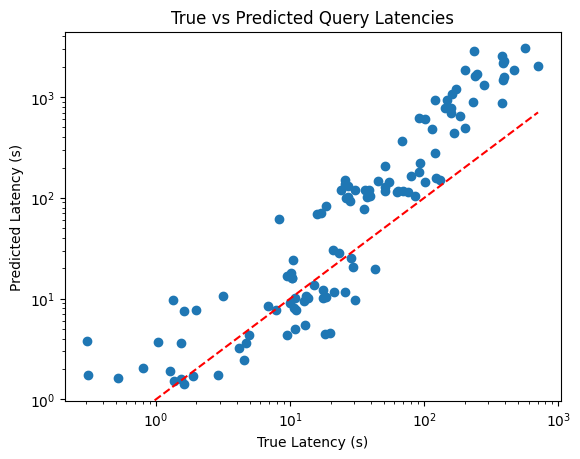

In [67]:
true_y = trace.latencies_s
predicted_y = predictions
plot_true_predicted(true_y, predicted_y)


In [57]:
from autoslo.nn.concurrent_query_dataset import ConcurrentQueryDataset
import os

dataset = ConcurrentQueryDataset.load_from(
    os.path.join(model._save_dir, "dataset.pkl")
)

In [58]:
from torch.utils.data import DataLoader, Subset
import torch
train_config  = model._train_config_sequence[-1]
train_idxs, val_idxs, test_idxs = model._get_data_splits(
    len(dataset), train_config
)
train_dataset = Subset(dataset, train_idxs)
val_dataset = Subset(dataset, val_idxs)
train_generator = torch.Generator()
train_generator.manual_seed(
    train_config.training_dataloader_shuffle_seed
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=train_config.batch_size,
    shuffle=True,
    generator=train_generator,
    collate_fn=ConcurrentQueryDataset.collate_and_pad,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=train_config.batch_size,
    shuffle=False,
    collate_fn=ConcurrentQueryDataset.collate_and_pad,
)

In [59]:
import pandas as pd
regenerated_query_id_hashes = set()
for batch in val_dataloader:
    _, _, _, _, query_id_hashes = batch
    regenerated_query_id_hashes.update([t.item() for t in query_id_hashes])

path = "/home/markakis/chunkbench/data/iconq_models/1767524004/val_predictions_10.csv"
val_predictions_df = pd.read_csv(path)
val_prediction_query_id_hashes = set(val_predictions_df["query_uuid"].tolist())
assert regenerated_query_id_hashes == val_prediction_query_id_hashes

In [60]:
val_predictions_df['y_pred_mean'] = val_predictions_df['y_pred'].apply(
    lambda x: float(x[x.find('[')+1 : x.find(']')])
)

In [61]:
val_predictions_df

,Unnamed: 0,query_uuid,y,y_pred,abs_error,q_error,percentile_at_true_latency,y_pred_mean
0,578,3488603667,3600.013400,"ModelPrediction(mean_s=array([3056.3413], dtyp...",543.672100,1.177883,1.0,3056.341300
1,72,3575392289,3600.010000,"ModelPrediction(mean_s=array([3008.2844], dtyp...",591.725600,1.196699,1.0,3008.284400
2,257,1684989432,3600.010000,"ModelPrediction(mean_s=array([3170.244], dtype...",429.766100,1.135562,1.0,3170.244000
3,963,375452724,3600.010000,"ModelPrediction(mean_s=array([3137.189], dtype...",462.821040,1.147527,1.0,3137.189000
4,130,2948633518,3600.010000,"ModelPrediction(mean_s=array([3119.7239], dtyp...",480.286130,1.153952,1.0,3119.723900
...,...,...,...,...,...,...,...,...
964,93,3931910140,0.141785,"ModelPrediction(mean_s=array([0.40748602], dty...",0.265701,2.873973,0.0,0.407486
965,792,1389041158,0.140791,"ModelPrediction(mean_s=array([0.60445607], dty...",0.463665,4.293288,0.0,0.604456
966,471,1682474248,0.131138,"ModelPrediction(mean_s=array([0.5651915], dtyp...",0.434053,4.309896,0.0,0.565191
967,639,2594822939,0.125033,"ModelPrediction(mean_s=array([0.48171645], dty...",0.356684,3.852718,0.0,0.481716


In [62]:
from tqdm import tqdm
predictions: dict[str, ModelPrediction] = {}



model._nn.eval()
with torch.no_grad():
    for x, x_len, pinch_points, _, query_id_hashes in tqdm(val_dataloader):
        x, x_len, pinch_points = (
            x.to(model._device),
            x_len.to(model._device),
            pinch_points.to(model._device),
        )

        y_pred_mean, y_pred_logvar, y_pred_mix = model._nn(
            x,
            x_len,
            pinch_points,
            mdn_mix_softmax_temperature=1.0,
        )

        if model._trained_on_log_runtime:
            y_pred_mean = torch.expm1(y_pred_mean)

        batch_size = x.size(0)
        for i in range(batch_size):
            query_id_hash = query_id_hashes[i].item()
            if model._nn_args["is_mdn"]:
                predictions[query_id_hash] = ModelPrediction(
                    mean_s=[
                        float(it) for it in y_pred_mean[i].tolist()
                    ],
                    std_dev_s=[
                        float(it)
                        for it in torch.exp(
                            y_pred_logvar[i] / 2
                        ).tolist()
                    ],
                    mix_coeffs=[
                        float(it) for it in y_pred_mix[i].tolist()
                    ],
                )
            elif model._nn_args["is_bayesian"]:
                predictions[query_id_hash] = ModelPrediction(
                    mean_s=[float(y_pred_mean[i].item())],
                    std_dev_s=[
                        float(torch.exp(y_pred_logvar[i] / 2).item())
                    ],
                )
            else:
                predictions[query_id_hash] = ModelPrediction(
                    mean_s=[float(y_pred_mean[i].item())],
                )

val_predictions_df['y_pred_mean_new'] = val_predictions_df['query_uuid'].apply(
    lambda qid: predictions[qid].overall_mean_s()
)

  0%|          | 0/31 [00:00<?, ?it/s]

100%|██████████| 31/31 [00:02<00:00, 12.17it/s]


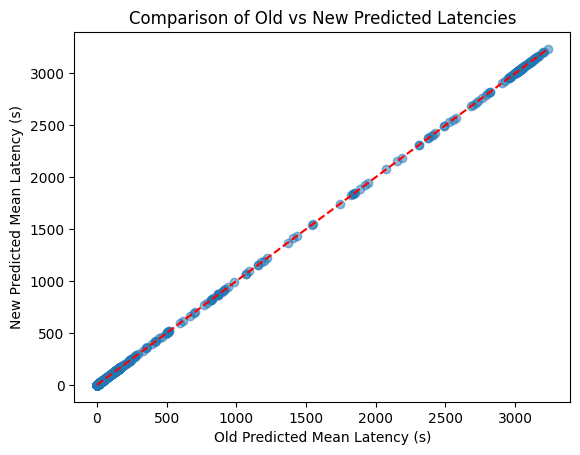

In [63]:
fig, ax = plt.subplots()
ax.scatter(
    val_predictions_df['y_pred_mean'],
    val_predictions_df['y_pred_mean_new'],
    alpha=0.5
)
ax.set_xlabel("Old Predicted Mean Latency (s)")
ax.set_ylabel("New Predicted Mean Latency (s)")
ax.set_title("Comparison of Old vs New Predicted Latencies")
plt.plot([0, max(val_predictions_df['y_pred_mean'])], [0, max(val_predictions_df['y_pred_mean'])], color='red', linestyle='--')  # Diagonal line
plt.show()